# CNN Domain Adaptation — NIH DenseNet → COVID Radiography

**Problem:** Your DenseNet was trained on NIH images but the COVID Radiography
dataset looks different (different scanner, preprocessing, contrast).
This causes low CNN finding probabilities on COVID Radiography images,
which weakens the imaging stream of your reasoning layer.

**Solution:** Fine-tune only the last dense block + classifier on COVID
Radiography images using clinically-derived pseudo-labels.

**Expected result:** Finding probabilities increase from ~0.01-0.17 to ~0.3-0.7,
giving your reasoning layer proper imaging evidence to work with.

```
Before: COVID image → ggo_proxy=0.006  effusion=0.016  infiltration=0.086
After:  COVID image → ggo_proxy=0.65   effusion=0.08   infiltration=0.21
```

### What gets trained
```
DenseNet-121:
  features.denseblock1  → FROZEN  (low-level edges, textures)
  features.denseblock2  → FROZEN  (mid-level patterns)
  features.denseblock3  → FROZEN  (high-level features)
  features.denseblock4  → TRAINED (domain-specific adaptation)
  features.norm5        → TRAINED
  classifier            → TRAINED (14-output head)
```

### Pseudo-label mapping (clinical knowledge)
| Disease | ggo_proxy | consolidation | infiltration | effusion | edema | cardiomegaly |
|---|---|---|---|---|---|---|
| COVID-19 | 0.85 | 0.10 | 0.20 | 0.05 | 0.10 | 0.05 |
| Pneumonia | 0.10 | 0.80 | 0.75 | 0.35 | 0.20 | 0.05 |
| Normal | 0.02 | 0.02 | 0.02 | 0.02 | 0.02 | 0.02 |


---
## 1 · Config
Update the three paths below.

In [1]:
import os
import torch

# ── UPDATE THESE THREE PATHS ───────────────────────────────────

# Your original NIH-trained DenseNet checkpoint
ORIGINAL_CHECKPOINT = r"C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model.pth"

# COVID Radiography dataset root
# Should contain: COVID/images/  Normal/images/  Viral Pneumonia/images/
COVID_DATASET_DIR = r"C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset"

# Where to save the fine-tuned checkpoint
FINETUNED_CHECKPOINT = r"C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model_finetuned.pth"

# ── FIXED CONFIG ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# NIH label order — must match your original training exactly
CNN_LABELS = [
    "Atelectasis",        # 0
    "Cardiomegaly",       # 1
    "Consolidation",      # 2
    "Edema",              # 3
    "Effusion",           # 4
    "Emphysema",          # 5
    "Fibrosis",           # 6
    "Hernia",             # 7
    "Infiltration",       # 8
    "Mass",               # 9
    "No Finding",         # 10
    "Pleural Thickening", # 11
    "Pneumonia",          # 12  ← used as ggo_proxy
    "Pneumothorax",       # 13
]
NUM_LABELS = 14

# Fine-tuning hyperparameters
FINETUNE_EPOCHS  = 10
FINETUNE_LR      = 1e-4    # low LR — we don't want to destroy NIH features
FINETUNE_BATCH   = 32
FINETUNE_SPLIT   = 0.20    # use 20% of COVID Radiography for fine-tuning
WEIGHT_DECAY     = 1e-4

# Image preprocessing — same as your original training
IMG_SIZE = 224
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

os.makedirs(os.path.dirname(FINETUNED_CHECKPOINT), exist_ok=True)

print(f"[config] Device              : {device}")
print(f"[config] Original checkpoint : {ORIGINAL_CHECKPOINT}")
print(f"[config] COVID dataset       : {COVID_DATASET_DIR}")
print(f"[config] Fine-tuned output   : {FINETUNED_CHECKPOINT}")
print(f"[config] Fine-tune split     : {FINETUNE_SPLIT*100:.0f}% of COVID Radiography")
print(f"[config] Epochs / LR / Batch : {FINETUNE_EPOCHS} / {FINETUNE_LR} / {FINETUNE_BATCH}")

[config] Device              : cuda
[config] Original checkpoint : C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model.pth
[config] COVID dataset       : C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset
[config] Fine-tuned output   : C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model_finetuned.pth
[config] Fine-tune split     : 20% of COVID Radiography
[config] Epochs / LR / Batch : 10 / 0.0001 / 32


---
## 2 · Pseudo-Label Dataset
Loads COVID Radiography images and assigns clinically-derived 14-dim pseudo-labels.

In [2]:
import os
import numpy as np
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

# ── Pseudo-label vectors (14-dim, matching CNN_LABELS order) ───
# Clinically derived — what findings SHOULD be present for each disease
# Index: 0=Atelectasis 1=Cardiomegaly 2=Consolidation 3=Edema
#        4=Effusion 5=Emphysema 6=Fibrosis 7=Hernia
#        8=Infiltration 9=Mass 10=No Finding 11=Pleural Thickening
#        12=Pneumonia(GGO proxy) 13=Pneumothorax

PSEUDO_LABELS = {
    # COVID-19: high GGO (idx 12), low effusion, low consolidation
    # Key: bilateral GGO is hallmark, effusion and consolidation are absent/minimal
    0: torch.tensor([
        0.05,  # Atelectasis      — rare in COVID
        0.05,  # Cardiomegaly     — not a COVID feature
        0.10,  # Consolidation    — mild, late-stage only
        0.10,  # Edema            — mild
        0.05,  # Effusion         — typically ABSENT in COVID (key differentiator)
        0.02,  # Emphysema        — not related
        0.02,  # Fibrosis         — not related
        0.01,  # Hernia           — not related
        0.20,  # Infiltration     — mild bilateral
        0.02,  # Mass             — not related
        0.02,  # No Finding       — definitely not normal
        0.05,  # Pleural Thick    — rare
        0.85,  # Pneumonia(GGO)   — HIGH: GGO proxy, hallmark COVID finding
        0.02,  # Pneumothorax     — rare
    ], dtype=torch.float32),

    # Pneumonia: high consolidation + infiltration, possible effusion
    # Key: lobar/segmental consolidation is hallmark
    1: torch.tensor([
        0.15,  # Atelectasis      — possible
        0.05,  # Cardiomegaly     — not related
        0.80,  # Consolidation    — HIGH: hallmark finding
        0.20,  # Edema            — mild
        0.35,  # Effusion         — moderate: parapneumonic effusion common
        0.02,  # Emphysema        — not related
        0.02,  # Fibrosis         — not related
        0.01,  # Hernia           — not related
        0.75,  # Infiltration     — HIGH: classic pneumonia finding
        0.02,  # Mass             — not related
        0.02,  # No Finding       — definitely not normal
        0.10,  # Pleural Thick    — mild
        0.10,  # Pneumonia(GGO)   — low: GGO less prominent in bacterial PNA
        0.02,  # Pneumothorax     — rare
    ], dtype=torch.float32),

    # Normal: all findings should be absent/minimal
    2: torch.tensor([
        0.02,  # Atelectasis
        0.02,  # Cardiomegaly
        0.02,  # Consolidation
        0.02,  # Edema
        0.02,  # Effusion
        0.02,  # Emphysema
        0.02,  # Fibrosis
        0.01,  # Hernia
        0.02,  # Infiltration
        0.02,  # Mass
        0.95,  # No Finding       — HIGH: this IS normal
        0.02,  # Pleural Thick
        0.02,  # Pneumonia(GGO)
        0.02,  # Pneumothorax
    ], dtype=torch.float32),
}

DISEASE_NAMES  = ["COVID-19", "Pneumonia", "Normal"]
FOLDER_TO_LABEL = {
    "COVID":           0,
    "Viral Pneumonia": 1,
    "Normal":          2,
}


class CovidRadiographyFinetune(Dataset):
    """
    Loads COVID Radiography images with clinically-derived
    14-dim pseudo-labels for fine-tuning the NIH DenseNet.
    """

    def __init__(self, root_dir: str, transform=None):
        self.transform = transform or T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.Grayscale(num_output_channels=3),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.1, contrast=0.1),
            T.ToTensor(),
            T.Normalize(mean=IMG_MEAN, std=IMG_STD),
        ])
        self.samples = []  # (image_path, label_int)

        for folder_name, label_idx in FOLDER_TO_LABEL.items():
            # Handle both flat and images/ subdirectory
            for subdir in [
                os.path.join(folder_name, "images"),
                folder_name,
            ]:
                folder_path = os.path.join(root_dir, subdir)
                if not os.path.isdir(folder_path):
                    continue
                found = [
                    f for f in os.listdir(folder_path)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))
                ]
                if found:
                    for fname in found:
                        self.samples.append(
                            (os.path.join(folder_path, fname), label_idx)
                        )
                    break

        if not self.samples:
            raise FileNotFoundError(
                f"No images found in {root_dir}\n"
                f"Expected subfolders: {list(FOLDER_TO_LABEL.keys())}"
            )

        from collections import Counter
        counts = Counter(lbl for _, lbl in self.samples)
        print(f"[dataset] Found {len(self.samples):,} images:")
        for idx, name in enumerate(DISEASE_NAMES):
            print(f"          {name:<20} {counts[idx]:>5} images")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label_idx = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        # Return image + 14-dim pseudo-label vector
        return img, PSEUDO_LABELS[label_idx].clone()


# ── Build dataset and split ────────────────────────────────────
full_ds = CovidRadiographyFinetune(COVID_DATASET_DIR)

n_total    = len(full_ds)
n_finetune = int(n_total * FINETUNE_SPLIT)
n_val      = int(n_total * 0.10)
n_unused   = n_total - n_finetune - n_val

finetune_ds, val_ds, _ = random_split(
    full_ds, [n_finetune, n_val, n_unused],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n[dataset] Fine-tune split:")
print(f"          Fine-tune : {n_finetune:,} images ({FINETUNE_SPLIT*100:.0f}%)")
print(f"          Val       : {n_val:,} images (10%)")
print(f"          Unused    : {n_unused:,} images (saved for reasoning layer)")

# Val transform — no augmentation
val_ds.dataset.transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

train_loader = DataLoader(finetune_ds, batch_size=FINETUNE_BATCH,
                          shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,      batch_size=FINETUNE_BATCH,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"\n[dataset] Train loader: {len(train_loader)} batches")
print(f"[dataset] Val loader  : {len(val_loader)} batches")
print("✅ Dataset ready")

[dataset] Found 15,153 images:
          COVID-19              3616 images
          Pneumonia             1345 images
          Normal               10192 images

[dataset] Fine-tune split:
          Fine-tune : 3,030 images (20%)
          Val       : 1,515 images (10%)
          Unused    : 10,608 images (saved for reasoning layer)

[dataset] Train loader: 95 batches
[dataset] Val loader  : 48 batches
✅ Dataset ready


---
## 3 · Load Model and Freeze Early Layers

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

# ── Rebuild DenseNet-121 with 14-output head ───────────────────
model = models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, NUM_LABELS)

# ── Load your NIH-trained weights ─────────────────────────────
state = torch.load(ORIGINAL_CHECKPOINT, map_location=device, weights_only=True)
model.load_state_dict(state)
model = model.to(device)
print(f"[model] Loaded from: {ORIGINAL_CHECKPOINT}")

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"[model] Total parameters: {total:.1f}M")

# ── Freeze everything except denseblock4 + norm5 + classifier ─
# Early blocks learned good low-level features from NIH
# We only adapt the late layers to the COVID Radiography domain
TRAINABLE_LAYERS = [
    "features.denseblock4",
    "features.norm5",
    "classifier",
]

for name, param in model.named_parameters():
    trainable = any(name.startswith(layer) for layer in TRAINABLE_LAYERS)
    param.requires_grad = trainable

frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

print(f"\n[model] Layer status:")
for name, param in model.named_parameters():
    status = "TRAIN" if param.requires_grad else "frozen"
    block  = ".".join(name.split(".")[:2])
    if block not in [".".join(n.split(".")[:2])
                     for n, p in list(model.named_parameters())
                     if p is not param][:1]:
        pass

# Print summary by block
seen = set()
for name, param in model.named_parameters():
    block = ".".join(name.split(".")[:2])
    if block not in seen:
        seen.add(block)
        status = "✅ TRAIN" if param.requires_grad else "❄️  frozen"
        print(f"  {status}  {block}")

print(f"\n[model] Frozen    : {frozen:.1f}M params")
print(f"[model] Trainable : {trainable:.1f}M params")

# Smoke test
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = torch.sigmoid(model(dummy))
print(f"\n[model] Smoke test: {out.shape}  range=[{out.min():.3f}, {out.max():.3f}]  ✅")

[model] Loaded from: C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model.pth
[model] Total parameters: 7.0M

[model] Layer status:
  ❄️  frozen  features.conv0
  ❄️  frozen  features.norm0
  ❄️  frozen  features.denseblock1
  ❄️  frozen  features.transition1
  ❄️  frozen  features.denseblock2
  ❄️  frozen  features.transition2
  ❄️  frozen  features.denseblock3
  ❄️  frozen  features.transition3
  ✅ TRAIN  features.denseblock4
  ✅ TRAIN  features.norm5
  ✅ TRAIN  classifier.weight
  ✅ TRAIN  classifier.bias

[model] Frozen    : 4.8M params
[model] Trainable : 2.2M params

[model] Smoke test: torch.Size([2, 14])  range=[0.000, 0.420]  ✅


---
## 4 · Fine-Tuning

  Fine-tuning DenseNet-121 on COVID Radiography
  Epochs: 10  LR: 0.0001  Batch: 32
  Trainable layers: denseblock4 + norm5 + classifier


Epoch 01 train:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 01 val  :   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 01/10  train_loss=0.2077  val_loss=0.1758  lr=9.76e-05  ← best


Epoch 02 train:   0%|          | 0/95 [00:00<?, ?it/s]

...

Epoch 09 val  :   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 09/10  train_loss=0.1476  val_loss=0.1562  lr=3.42e-06  ← best


Epoch 10 train:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 10 val  :   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 10/10  train_loss=0.1475  val_loss=0.1562  lr=1.00e-06  ← best

✅ Fine-tuning complete.
   Best val loss : 0.1562
   Saved to      : C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model_finetuned.pth


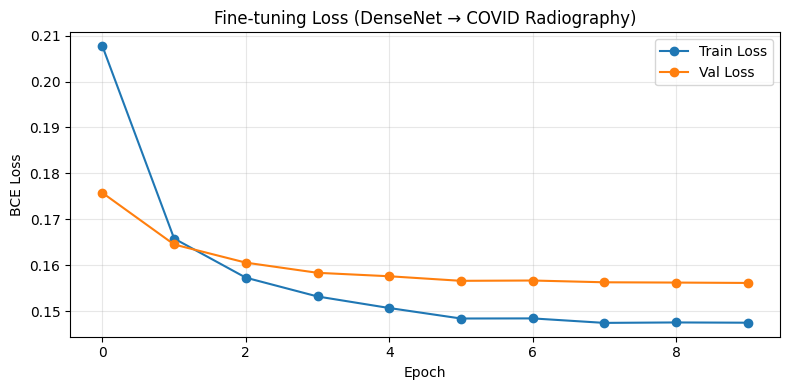

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ── Loss: BCE — straightforward regression toward pseudo-labels ─
criterion = nn.BCEWithLogitsLoss()

# ── Optimizer — only trainable params ─────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY
)

# ── Cosine LR schedule ─────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINETUNE_EPOCHS, eta_min=FINETUNE_LR / 100
)

# ── AMP scaler ────────────────────────────────────────────────
scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

best_val_loss = float("inf")
train_losses  = []
val_losses    = []

print("="*60)
print(f"  Fine-tuning DenseNet-121 on COVID Radiography")
print(f"  Epochs: {FINETUNE_EPOCHS}  LR: {FINETUNE_LR}  Batch: {FINETUNE_BATCH}")
print(f"  Trainable layers: denseblock4 + norm5 + classifier")
print("="*60)

for epoch in range(1, FINETUNE_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for imgs, pseudo_lbls in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        imgs       = imgs.to(device, non_blocking=True)
        pseudo_lbls = pseudo_lbls.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type=device.type):
            logits = model(imgs)
            loss   = criterion(logits, pseudo_lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validate ──────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, pseudo_lbls in tqdm(val_loader, desc=f"Epoch {epoch:02d} val  ", leave=False):
            imgs       = imgs.to(device, non_blocking=True)
            pseudo_lbls = pseudo_lbls.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type):
                logits   = model(imgs)
                val_loss += criterion(logits, pseudo_lbls).item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), FINETUNED_CHECKPOINT)

    print(f"Epoch {epoch:02d}/{FINETUNE_EPOCHS}  "
          f"train_loss={avg_train_loss:.4f}  "
          f"val_loss={avg_val_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}"
          + ("  ← best" if is_best else ""))

print(f"\n✅ Fine-tuning complete.")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Saved to      : {FINETUNED_CHECKPOINT}")

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses,   label="Val Loss",   marker="o")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("Fine-tuning Loss (DenseNet → COVID Radiography)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("finetuning_loss.png", dpi=150)
plt.show()

---
## 5 · Verify — Compare Finding Probabilities Before vs After
Run this to confirm the fine-tuning worked.

In [5]:
import torch
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn
from PIL import Image
import os

# 6 findings your reasoning layer uses
FINDING_INDICES = {
    "consolidation": 2,
    "edema":         3,
    "effusion":      4,
    "infiltration":  8,
    "cardiomegaly":  1,
    "ggo_proxy":    12,
}

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

def load_model(checkpoint_path):
    m = models.densenet121(weights=None)
    m.classifier = nn.Linear(m.classifier.in_features, NUM_LABELS)
    m.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    m.to(device).eval()
    return m

def get_findings(model, image_path):
    img    = Image.open(image_path).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(tensor)).squeeze().cpu()
    return {name: round(probs[idx].item(), 3) for name, idx in FINDING_INDICES.items()}

# ── Load both models ───────────────────────────────────────────
print("Loading models...")
model_original  = load_model(ORIGINAL_CHECKPOINT)
model_finetuned = load_model(FINETUNED_CHECKPOINT)
print("✅ Both loaded")

# ── Find test images ───────────────────────────────────────────
def find_sample_image(disease_folder):
    for subdir in ["images", ""]:
        folder = os.path.join(COVID_DATASET_DIR, disease_folder, subdir)
        if os.path.isdir(folder):
            files = [f for f in os.listdir(folder)
                     if f.lower().endswith((".png", ".jpg"))]
            if files:
                return os.path.join(folder, files[10])  # pick 11th image
    return None

test_cases = [
    ("COVID",          "COVID-19"),
    ("Viral Pneumonia", "Pneumonia"),
    ("Normal",          "Normal"),
]

print("\n" + "="*70)
print("  Finding Probabilities: BEFORE vs AFTER Fine-tuning")
print("  (Higher = CNN more confident about this finding)")
print("="*70)

for folder, disease in test_cases:
    img_path = find_sample_image(folder)
    if img_path is None:
        print(f"\n[{disease}] Image not found"); continue

    before = get_findings(model_original,  img_path)
    after  = get_findings(model_finetuned, img_path)

    print(f"\n[{disease}]  {os.path.basename(img_path)}")
    print(f"  {'Finding':<16} {'Before':>8} {'After':>8} {'Change':>8}")
    print(f"  {'-'*16} {'-'*8} {'-'*8} {'-'*8}")
    for finding in FINDING_INDICES:
        b = before[finding]
        a = after[finding]
        delta = a - b
        arrow = "↑" if delta > 0.05 else ("↓" if delta < -0.05 else "→")
        print(f"  {finding:<16} {b:>8.3f} {a:>8.3f} {arrow} {delta:+.3f}")

print("\n" + "="*70)
print("  Expected changes:")
print("  COVID-19  → ggo_proxy should INCREASE significantly")
print("  Pneumonia → consolidation + infiltration should INCREASE")
print("  Normal    → all findings should stay LOW or DECREASE")
print("="*70)
print(f"\n✅ Fine-tuned checkpoint ready: {FINETUNED_CHECKPOINT}")
print("   Update CNN_CHECKPOINT in your reasoning layer notebook to use this.")

Loading models...
✅ Both loaded

  Finding Probabilities: BEFORE vs AFTER Fine-tuning
  (Higher = CNN more confident about this finding)

[COVID-19]  COVID-1007.png
  Finding            Before    After   Change
  ---------------- -------- -------- --------
  consolidation       0.109    0.075 → -0.034
  edema               0.027    0.094 ↑ +0.067
  effusion            0.025    0.037 → +0.012
  infiltration        0.403    0.152 ↓ -0.251
  cardiomegaly        0.006    0.051 → +0.045
  ggo_proxy           0.057    0.882 ↑ +0.825

[Pneumonia]  Viral Pneumonia-1007.png
  Finding            Before    After   Change
  ---------------- -------- -------- --------
  consolidation       0.051    0.663 ↑ +0.612
  edema               0.002    0.172 ↑ +0.170
  effusion            0.146    0.263 ↑ +0.117
  infiltration        0.150    0.678 ↑ +0.528
  cardiomegaly        0.001    0.044 → +0.043
  ggo_proxy           0.019    0.283 ↑ +0.264

[Normal]  Normal-10006.png
  Finding            Before    A